Processing dataset: NC_nuebar


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_2882/287546170.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


Number of events with mu+ energy > 100: 52451
Total number of MC events for NC_nuebar: 52451
Total number of detector events for NC_nuebar: 737.9601916876929
Processing dataset: NC_numu


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_2882/287546170.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


Number of events with mu+ energy > 100: 46658
Total number of MC events for NC_numu: 46658
Total number of detector events for NC_numu: 1714.128537488932
Processing dataset: CC_numu


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_2882/287546170.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


Number of events with mu+ energy > 100: 262805
Total number of MC events for CC_numu: 262805
Total number of detector events for CC_numu: 32294.044762558256
Processing dataset: CC_nuebar


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_2882/287546170.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


Number of events with mu+ energy > 100: 52451
Total number of MC events for CC_nuebar: 52451
Total number of detector events for CC_nuebar: 2026.7900640333319


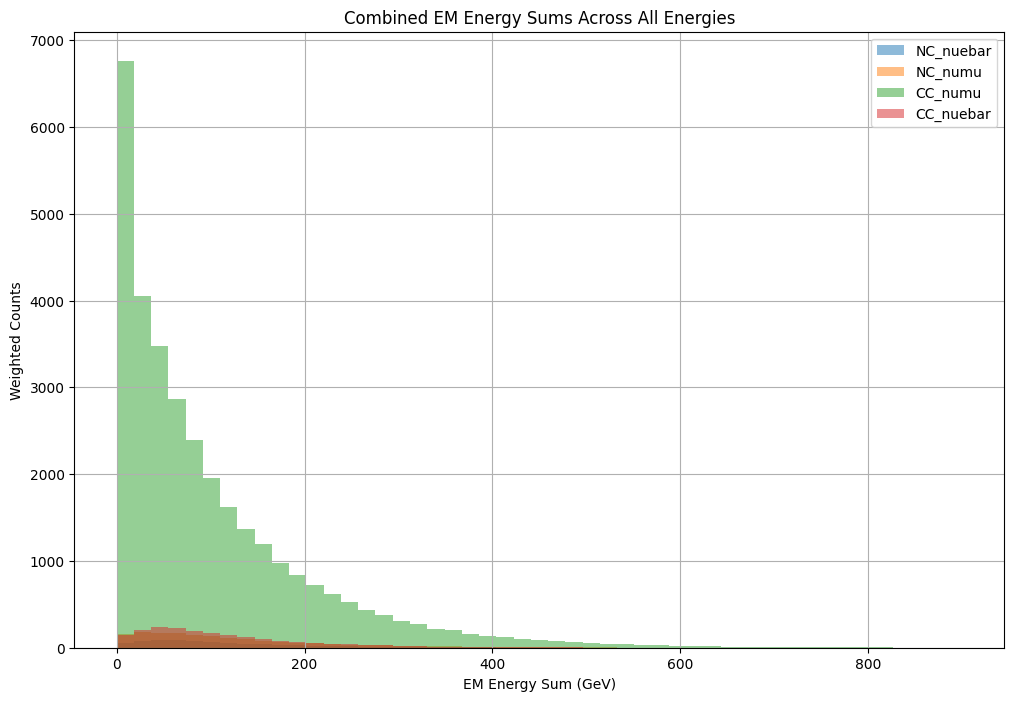

In [2]:
import os
import pandas as pd
import numpy as np
import json
from collections import defaultdict
import matplotlib.pyplot as plt

def fix_dataframe(data):

    # Initialize the column 'ievent' with zeros
    data['ievent'] = 0
    # Variable to keep track of the increment for column 'ievent'
    counter = 0
    # Loop through the DataFrame rows
    for index, row in data.iterrows():
        if row['iparticle'] == 0: counter += 1
        data.at[index, 'ievent'] = counter
    #return
    return data

def read_cross_sections(file_path, dataset, flux_column):
    """
    Reads energies, cross-sections, and fluxes from the file for a specific dataset and flux column.
    """
    try:
        df = pd.read_csv(file_path, delim_whitespace=True)
        if 'energy' not in df.columns or dataset not in df.columns or flux_column not in df.columns:
            raise ValueError("Required columns ('energy', dataset, and flux_column) are missing.")
        
        # Use the integer part of energy as the key
        cross_sections = dict(zip(df['energy'].astype(int), df[dataset]))
        fluxes = dict(zip(df['energy'].astype(int), df[flux_column]))
        return cross_sections, fluxes
    except Exception as e:
        print(f"Error reading cross-section file {file_path}: {e}")
        return {}, {}

def parse_events_from_csv(filepath):
    """
    Parses events from a CSV file, fixing 'ievent' if necessary.
    """
    try:
        df = pd.read_csv(filepath)
        
        # Fix the dataframe to correctly populate 'ievent'
        df = fix_dataframe(df)
        
        events = []
        for _, group in df.groupby('ievent'):
            event = []
            for _, row in group.iterrows():
                event.append((row['pid'], row['px'], row['py'], row['pz'], row['e'], row['parent_pid1'], row['parent_pid2']))
            events.append(event)
        return events
    except Exception as e:
        print(f"Error reading events from file {filepath}: {e}")
        return []

def count_muon_events(directory, threshold, prefix, suffix, cross_section_dict):
    """
    Counts muon events and calculates EM energy sums.
    """
    EM_energy_sums = defaultdict(list)
    num_events_above_threshold = 0
    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            # Extract energy from the filename
            try:
                energy = float(filename[len(prefix):-len(suffix)].split('_')[-1])
                energy_key = int(energy)  # Use the integer part of the energy
            except ValueError:
                print(f"Could not extract energy from filename: {filename}")
                continue

            # Check if the energy exists in cross_section_dict
            cross_section = cross_section_dict.get(energy_key)
            if cross_section is None:
                print(f"No cross-section found for energy: {energy_key}")
                continue

            # Parse events
            filepath = os.path.join(directory, filename)
            events = parse_events_from_csv(filepath)

            excluded_pids = [11, 22, -11]
            for event in events:
                max_muon_plus_energy = 0  # Track the maximum energy of mu+
                EM_energy_sum = 0

                for pid, px, py, pz, e, _, _ in event:
                    if pid == -13:  # Check for mu+
                        max_muon_plus_energy = max(max_muon_plus_energy, e)  # Update max energy
                    elif pid in excluded_pids:  # Check for excluded particles
                        EM_energy_sum += e

                # Check if the maximum mu+ energy exceeds the threshold
                if max_muon_plus_energy > threshold:
                    EM_energy_sums[energy_key].append(EM_energy_sum)
                    num_events_above_threshold += 1  # Increment the count for this event

    print(f"Number of events with mu+ energy > {threshold}: {num_events_above_threshold}")
    return EM_energy_sums

def main():
    datasets = {
        # Mapping datasets to directories, prefixes, suffixes, and corresponding flux columns
        'NC_nuebar': ('output_events_NC_nuebar', 'events_', '.csv.zip', 'nuebar_flux'),
        'NC_numu': ('output_events_NC_numu', 'events_', '.csv.zip', 'numu_flux'),
        'CC_numu': ('output_events_CC_numu', 'events_', '.csv.zip', 'numu_flux'),
        'CC_nuebar': ('output_events_NC_nuebar', 'events_', '.csv.zip', 'nuebar_flux'),
    }
    
    # Initialize constants
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g 
    l_det = 4.0425         # length of detector for iron for 10 kg in cm
      
    scaling_factor = rho * l_det / mass    # area density, in 1/cm2
    cross_section_file = 'MC_-14_3TeV_with_cut_with_final-Copy1.txt'
    
    # Process each dataset
    plt.figure(figsize=(12, 8))
    
    for dataset_name, (directory_name, prefix, suffix, flux_column) in datasets.items():
        print(f"Processing dataset: {dataset_name}")
        
        # Load cross-sections and fluxes
        cross_section_dict, flux_dict = read_cross_sections(cross_section_file, dataset_name, flux_column)
        if not cross_section_dict or not flux_dict:
            print(f"No cross-sections or fluxes available for {dataset_name}. Skipping.")
            continue

        # Load event numbers (nevent) from the JSON file
        generated_data_file = f"{directory_name}/generated_events.json"
        try:
            with open(generated_data_file, "r") as f:
                generated_data = json.load(f)
            generated_data = {int(float(key)): value for key, value in generated_data.items()}
        except Exception as e:
            print(f"Error loading generated_events.json for {dataset_name}: {e}")
            continue
        
        threshold = 100  # Threshold for muon+
        EM_energy_sums = count_muon_events(directory_name, threshold, prefix, suffix, cross_section_dict)
        
        # Track the total number of muon+ events for this dataset
        total_events = 0

        # Combine energy sums and weights across all energies
        combined_energy_sums = []
        combined_weights = []
        MC_events = 0
        for energy, energy_sums in EM_energy_sums.items():
            nevent = generated_data.get(energy)
            if nevent is None:
                print(f"No event data found for energy: {energy}. Skipping this energy.")
                continue
            
            weight = ((cross_section_dict[energy] * flux_dict[energy] * scaling_factor) / nevent)
            combined_energy_sums.extend(energy_sums)
            combined_weights.extend([weight] * len(energy_sums))
            MC_events += len(energy_sums)
            # Increment total events count
            total_events += len(energy_sums) * weight
        
        # Print the total number of events for the dataset
        print(f"Total number of MC events for {dataset_name}: {MC_events}")
        print(f"Total number of detector events for {dataset_name}: {total_events}")
        
        # Plot the combined histogram for this dataset
        plt.hist(
            combined_energy_sums, 
            bins=np.linspace(0, 900, 50), 
            weights=combined_weights, 
            alpha=0.5, 
            label=f"{dataset_name}"
        )
    
    # Add plot labels and legend
    plt.xlabel('EM Energy Sum (GeV)')
    plt.ylabel('Weighted Counts')
    plt.title("Combined EM Energy Sums Across All Energies")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()
